# Importar librerías

In [3]:
import sys
from pathlib import Path

# Ajustar el path del proyecto para importar el módulo desde src/
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("No se encontró la carpeta 'src' en el árbol de directorios.")

# Importante: insertar la raíz del proyecto, no la carpeta src.
sys.path.insert(0, str(project_root.resolve()))
print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


# Librerías de simulación y análisis

In [80]:
import pandas as pd
pd.set_option('display.max_columns', 30)
import numpy as np

from src.simulacion_cumulo import (
    ClusterSimulationConfig,
    OpenClusterSimulator,
)
from src.vector_director import run_cluster_analysis_from_dataframe
from src.proper_motion_simulator import simulate_proper_motions_from_3d_velocity
from src.utils import show_cluster_validation_products_icrs

# Cargue de datos

In [34]:
cluster_real = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\dev\pasantia\analisis_detallado_hyades.csv")

# Configuración de simulaciones

## Configuración de sintéticas

In [47]:
#configuracion para generar cúmulo sintético de las hyades
config_hyades = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,
)

config_hyades_solar = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=262.6,
    apex_dec_deg=-81.9,

    speed_kms=25.0,
    seed=42,
)

config_hyades_error_parallax = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    parallax_error_mas=0.03,
)

config_hyades_error_pmra = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    pmra_error_masyr=0.03,
)

config_hyades_error_pmdec = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    pmdec_error_masyr=0.03,
)

config_hyades_error_pm = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    pmra_error_masyr=0.03,
    pmdec_error_masyr=0.03,
)

config_hyades_error_all = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    pmra_error_masyr=0.03,
    pmdec_error_masyr=0.03,
    parallax_error_mas=0.03,
)

config_hyades_error_dispersion = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    speed_sigma_kms=1
)


## generación de simulaciones sintéticas

In [48]:
# ejecución de simulación del cúmulo sintético de las hyades
simulator_hyades = OpenClusterSimulator(config_hyades)
simulator_hyades_solar = OpenClusterSimulator(config_hyades_solar)
simulator_hyades_error_parallax = OpenClusterSimulator(config_hyades_error_parallax)
simulator_hyades_error_pmra = OpenClusterSimulator(config_hyades_error_pmra)
simulator_hyades_error_pmdec = OpenClusterSimulator(config_hyades_error_pmdec)
simulator_hyades_error_pm = OpenClusterSimulator(config_hyades_error_pm)
simulator_hyades_error_all = OpenClusterSimulator(config_hyades_error_all)
simulator_hyades_error_dispersion = OpenClusterSimulator(config_hyades_error_dispersion)

hyades_sintetico = simulator_hyades.simulate()
hyades_sintetico["cluster_id"] ="0_8"
hyades_sintetico["grupo"] = "1"

hyades_sintetico_solar = simulator_hyades_solar.simulate()
hyades_sintetico_solar["cluster_id"] ="0_8"
hyades_sintetico_solar["grupo"] = "1"

hyades_sintetico_error_parallax = simulator_hyades_error_parallax.simulate()
hyades_sintetico_error_parallax["cluster_id"] ="0_8"
hyades_sintetico_error_parallax["grupo"] = "1"

hyades_sintetico_error_pmra = simulator_hyades_error_pmra.simulate()
hyades_sintetico_error_pmra["cluster_id"] ="0_8"
hyades_sintetico_error_pmra["grupo"] = "1"

hyades_sintetico_error_pmdec = simulator_hyades_error_pmdec.simulate()
hyades_sintetico_error_pmdec["cluster_id"] ="0_8"
hyades_sintetico_error_pmdec["grupo"] = "1"

hyades_sintetico_error_pm = simulator_hyades_error_pm.simulate()
hyades_sintetico_error_pm["cluster_id"] ="0_8"
hyades_sintetico_error_pm["grupo"] = "1"

hyades_sintetico_error_all = simulator_hyades_error_all.simulate()
hyades_sintetico_error_all["cluster_id"] ="0_8"
hyades_sintetico_error_all["grupo"] = "1"

hyades_sintetico_error_dispersion = simulator_hyades_error_dispersion.simulate()
hyades_sintetico_error_dispersion["cluster_id"] ="0_8"
hyades_sintetico_error_dispersion["grupo"] = "1"

## Generación de simulaciones semi-sintéticas

In [58]:
# Simulacion con valores reportados de velocidad
simulado_uvw = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    # Velocidad galáctica heliocéntrica U,V,W
    u_kms=-41.92,
    v_kms=-19.35,
    w_kms=-1.11,

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)
# Simulacion con el valor de apex del cumulo
simulado_apex = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=97.89,
    apex_dec_deg=6.61,
    speed_kms=np.sqrt(41.92**2 + 19.35**2 + 1.11**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax",

    apply_pmra_error=True,
    apply_pmdec_error=True,
    apply_parallax_error=False,

    seed=42,
)
simulado_uvw_solar = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    # Velocidad galáctica heliocéntrica U,V,W
    u_kms=11.1,
    v_kms=12.24,
    w_kms=7.25,

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)
# Simulacion con el valor de apex del cumulo
simulado_apex_solar = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=262.6,
    apex_dec_deg=-81.9,
    speed_kms=np.sqrt(11.1**2 + 12.24**2 + 7.25**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax",

    apply_pmra_error=True,
    apply_pmdec_error=True,
    apply_parallax_error=False,

    seed=42,
)

In [50]:
simulado_uvw[["apex_ra_deg","apex_dec_deg"]].describe()

,apex_ra_deg,apex_dec_deg
count,4.550000e+02,4.550000e+02
mean,9.789005e+01,6.617340e+00
std,5.690599e-13,3.645540e-14
min,9.789005e+01,6.617340e+00
25%,9.789005e+01,6.617340e+00
50%,9.789005e+01,6.617340e+00
75%,9.789005e+01,6.617340e+00
max,9.789005e+01,6.617340e+00


## generación de análisis sintéticos

In [64]:
# ejecucion de cálculo de ápex para cúmulo sintético
result_hyades_sintetico = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_solar = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_parallax = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_parallax,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_pmra = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pmra,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_pmdec = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pmdec,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)

result_hyades_sintetico_error_pm = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pm,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_all = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_all,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_dispersion = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_dispersion,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)

## Generación de resultados semi-sintéticos

In [60]:
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_velocidad = run_cluster_analysis_from_dataframe(
    df = simulado_uvw,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_apex = run_cluster_analysis_from_dataframe(
    df = simulado_apex,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_velocidad_solar = run_cluster_analysis_from_dataframe(
    df = simulado_uvw_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_apex_solar = run_cluster_analysis_from_dataframe(
    df = simulado_apex_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)

# Análisis de resultados

## Agrupación de resultados

In [72]:
all_results = {
    "Hy_s": result_hyades_sintetico["summary"],
    "Hy_s solar": result_hyades_sintetico_solar["summary"],
    "Hy_s err plx": result_hyades_sintetico_error_parallax["summary"],
    "Hy_s err pmra": result_hyades_sintetico_error_pmra["summary"],
    "Hy_s err pmdec": result_hyades_sintetico_error_pmdec["summary"],
    "Hy_s err pm": result_hyades_sintetico_error_pm["summary"],
    "Hy_s err all": result_hyades_sintetico_error_all["summary"],
    "Hy_s err dispersion": result_hyades_sintetico_error_dispersion["summary"],
    "Hy_s err pmra": result_hyades_sintetico_error_pmra["summary"],
    "Hy_ss vel": result_hyades_semisintetico_velocidad["summary"],
    "Hy_ss apex": result_hyades_semisintetico_apex["summary"], 
    "Hy_ss vel solar": result_hyades_semisintetico_velocidad_solar["summary"],
    "Hy_ss apex solar": result_hyades_semisintetico_apex_solar["summary"],
}

In [81]:
df_results = pd.DataFrame(
    [
        {
            "type": result_name,
            **result_dict,
        }
        for result_name, result_dict in all_results.items()
    ]
)

df_results

,type,cluster_id,n_stars,n_stars_initial,n_stars_refined,apex_initial_ra_deg,apex_initial_dec_deg,antapex_initial_ra_deg,antapex_initial_dec_deg,rms_pole_residual_initial_deg,median_pole_residual_initial_deg,toward_apex_fraction_initial,apex_refined_ra_deg,apex_refined_dec_deg,antapex_refined_ra_deg,antapex_refined_dec_deg,rms_pole_residual_refined_deg,median_pole_residual_refined_deg,toward_apex_fraction_refined,cross_initial_apex_ra_deg,cross_initial_apex_dec_deg,cross_initial_rms_residual_deg,cross_initial_n_pairs_used,cross_refined_apex_ra_deg,cross_refined_apex_dec_deg,cross_refined_rms_residual_deg,cross_refined_n_pairs_used
0,Hy_s,0_8,455,455,455,97.890002,6.620000,277.890002,-6.620000,8.611562e-08,6.711985e-08,1.0,97.890002,6.620000,277.890002,-6.620000,8.611562e-08,6.711985e-08,1.0,97.890008,6.619998,0.001374,103285,97.890008,6.619998,0.001374,103285
1,Hy_s solar,0_8,455,455,455,262.600000,-81.899999,82.600000,81.899999,2.060174e-08,1.483336e-08,1.0,262.600000,-81.899999,82.600000,81.899999,2.060174e-08,1.483336e-08,1.0,262.599997,-81.899998,0.000295,103285,262.599997,-81.899998,0.000295,103285
2,Hy_s err plx,0_8,455,455,455,97.890002,6.620000,277.890002,-6.620000,8.611562e-08,6.711985e-08,1.0,97.890002,6.620000,277.890002,-6.620000,8.611562e-08,6.711985e-08,1.0,97.890008,6.619998,0.001374,103285,97.890008,6.619998,0.001374,103285
3,Hy_s err pmra,0_8,455,455,455,97.892069,6.619370,277.892069,-6.619370,7.248040e-03,4.909112e-03,1.0,97.892069,6.619370,277.892069,-6.619370,7.248040e-03,4.909112e-03,1.0,97.881281,6.623834,3.303883,103285,97.881281,6.623834,3.303883,103285
4,Hy_s err pmdec,0_8,455,455,455,97.885905,6.622271,277.885905,-6.622271,2.610551e-02,1.786115e-02,1.0,97.885905,6.622271,277.885905,-6.622271,2.610551e-02,1.786115e-02,1.0,97.876894,6.624614,6.158009,103285,97.876894,6.624614,6.158009,103285
5,Hy_s err pm,0_8,455,455,455,97.871318,6.625765,277.871318,-6.625765,2.640652e-02,1.679867e-02,1.0,97.871318,6.625765,277.871318,-6.625765,2.640652e-02,1.679867e-02,1.0,97.886287,6.619485,6.302658,103285,97.886287,6.619485,6.302658,103285
6,Hy_s err all,0_8,455,455,455,97.860903,6.631378,277.860903,-6.631378,2.787582e-02,1.894264e-02,1.0,97.860903,6.631378,277.860903,-6.631378,2.787582e-02,1.894264e-02,1.0,97.852611,6.634088,6.530617,103285,97.852611,6.634088,6.530617,103285
7,Hy_s err dispersion,0_8,455,455,455,97.890002,6.620000,277.890002,-6.620000,9.233160e-08,6.653180e-08,1.0,97.890002,6.620000,277.890002,-6.620000,9.233160e-08,6.653180e-08,1.0,97.890005,6.619999,0.000953,103285,97.890005,6.619999,0.000953,103285
8,Hy_ss vel,0_8,455,455,455,97.890051,6.617340,277.890051,-6.617340,5.859968e-07,3.899918e-07,1.0,97.890051,6.617340,277.890051,-6.617340,5.859968e-07,3.899918e-07,1.0,97.890053,6.617339,0.001369,79800,97.890053,6.617339,0.001369,79800
9,Hy_ss apex,0_8,455,455,455,97.965711,6.574211,277.965711,-6.574211,6.147313e-02,2.184400e-02,1.0,97.965711,6.574211,277.965711,-6.574211,6.147313e-02,2.184400e-02,1.0,97.986781,6.568376,6.144710,79800,97.986781,6.568376,6.144710,79800



CLUSTER VALIDATION SUMMARY — ICRS / Gaia


,value
cluster_id,0_8
n_stars,455
n_stars_refined,455
fraction_kept,1.0
apex_ra_deg,262.6
apex_dec_deg,-81.899999
antapex_ra_deg,82.6
antapex_dec_deg,81.899999
rms_pole_residual_deg,0.0
median_pole_residual_deg,0.0



INTERPRETATION FLAGS
RMS pole residual          : 0.0000 deg
Median pole residual       : 0.0000 deg
Toward-apex fraction       : 1.0000
Fraction kept after filter : 1.0000
Apex-cross separation      : 0.0000 deg
Pole residuals             : GOOD, strong common-motion geometry.
Motion orientation         : GOOD, most stars move toward the recovered apex.
Apex estimator agreement   : GOOD, eigen and pole-cross estimators agree.


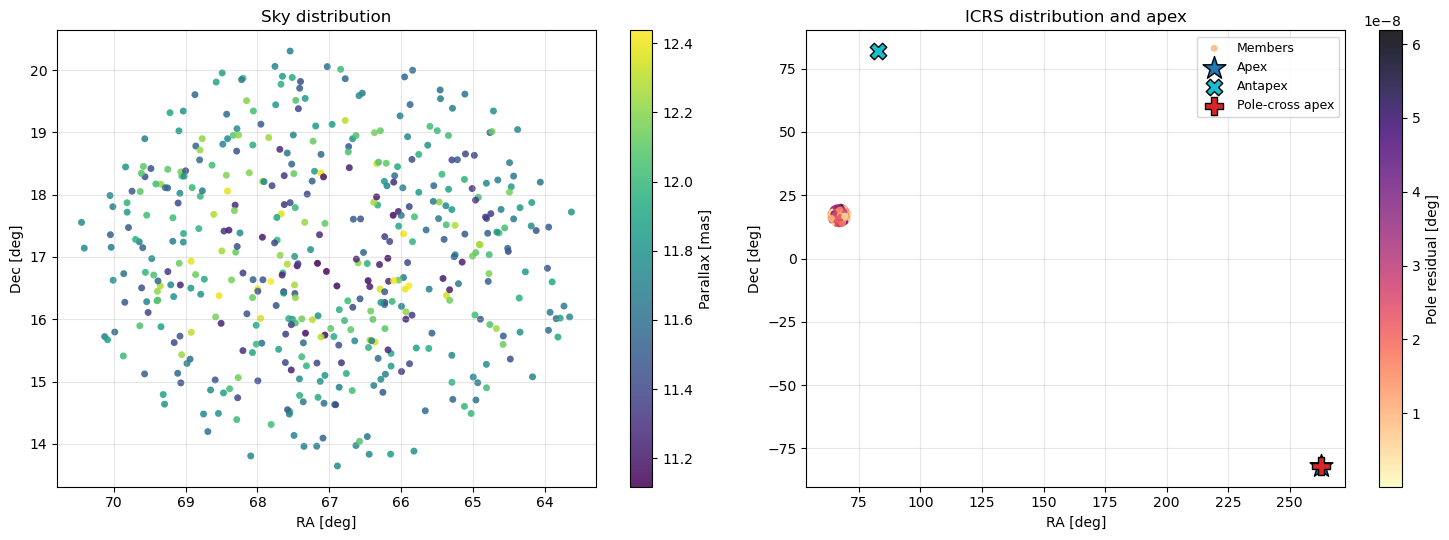

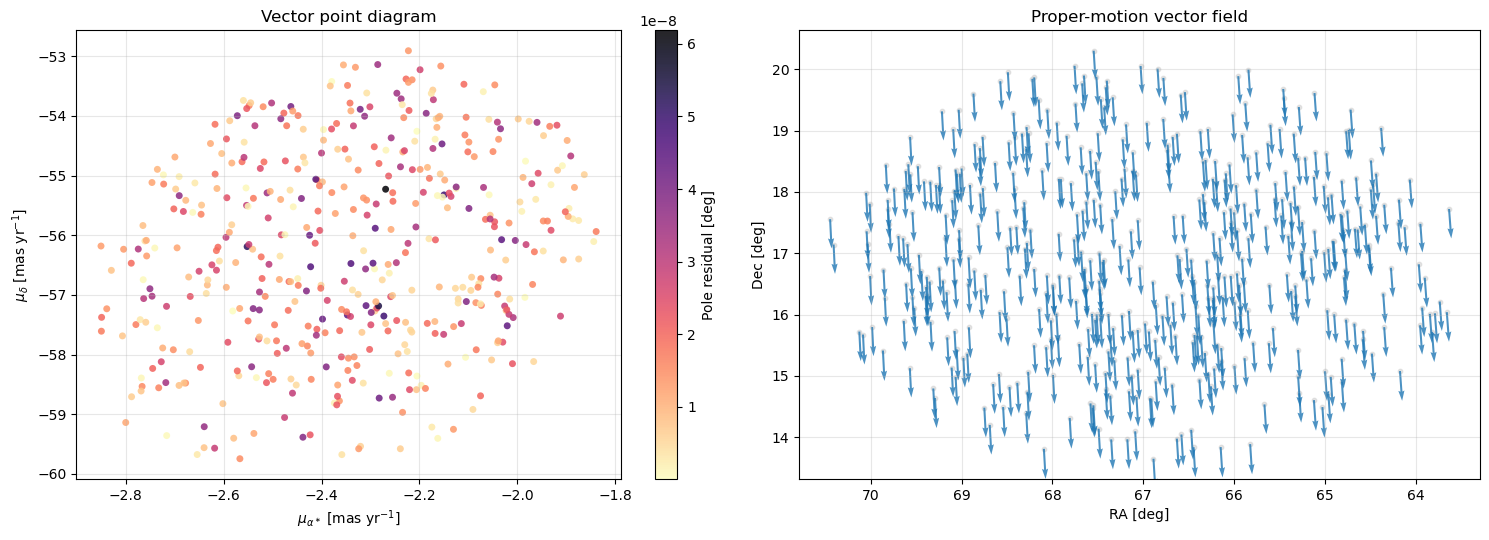

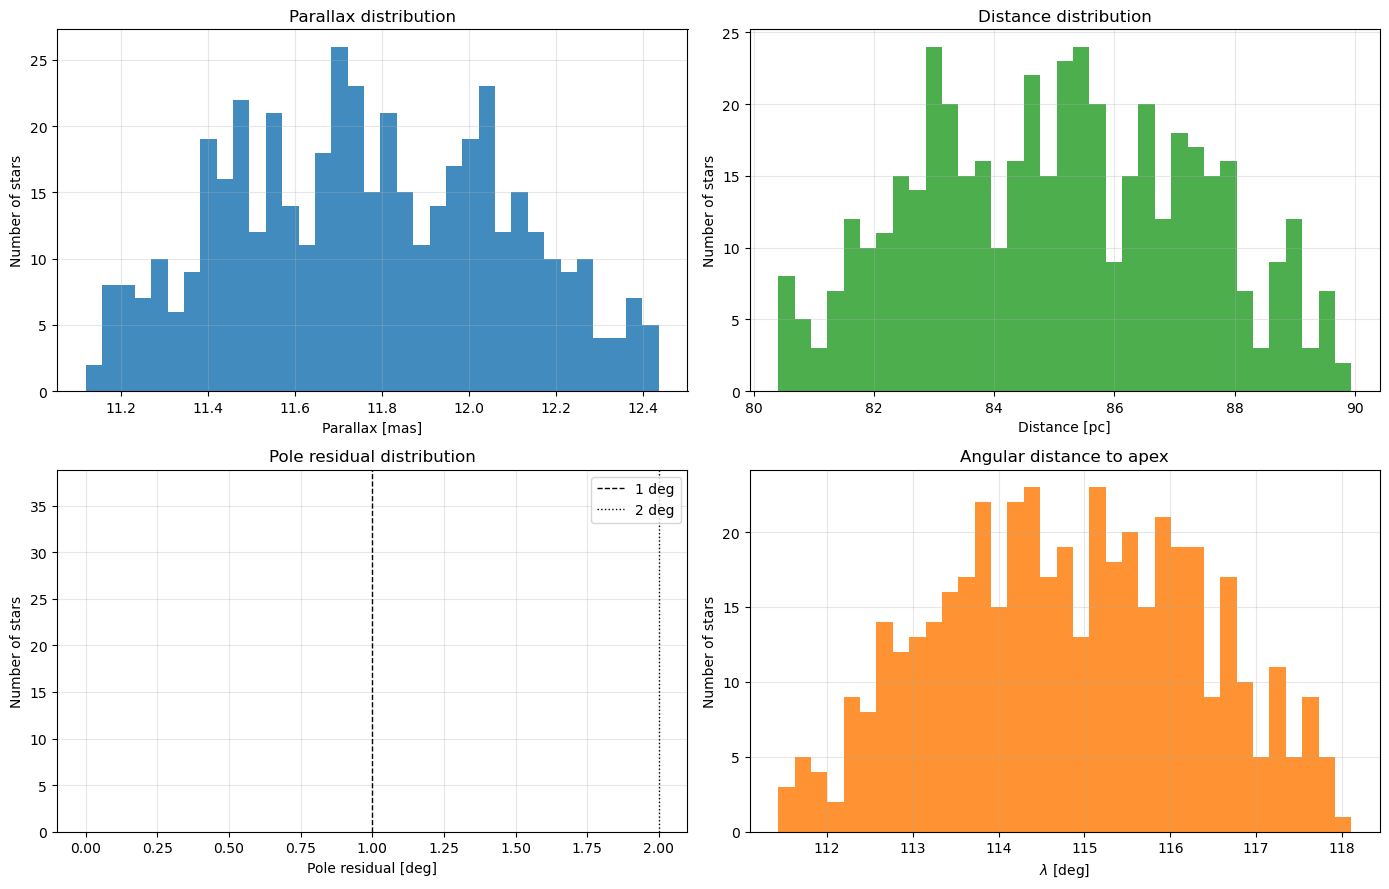

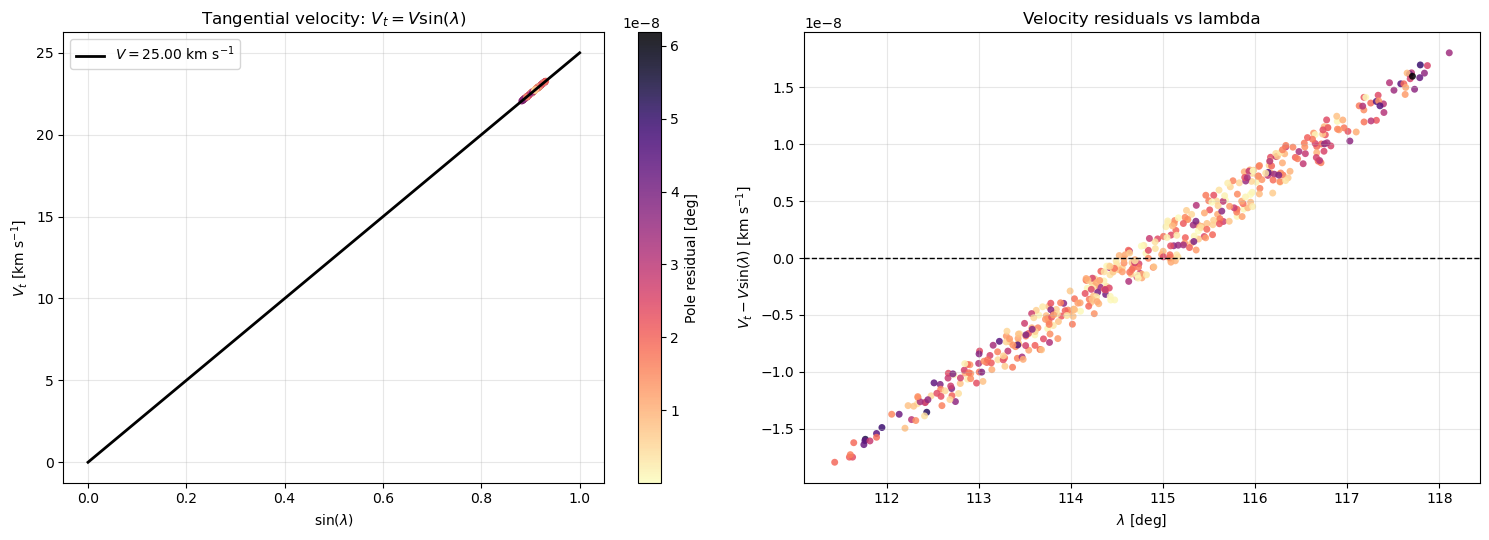

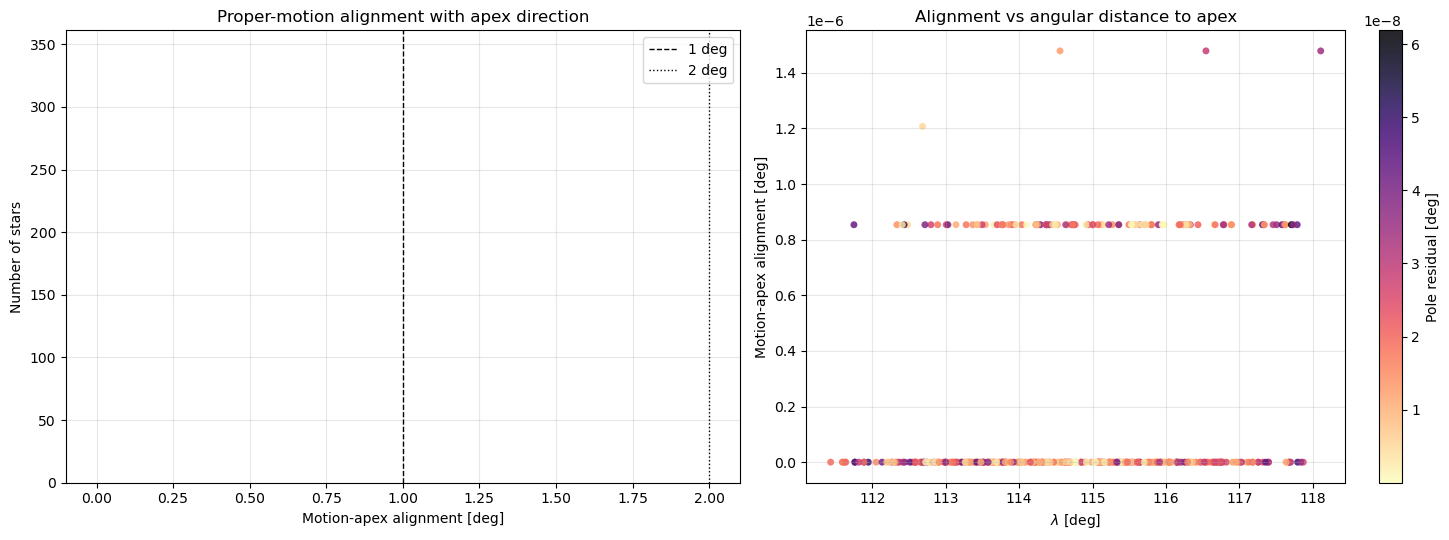

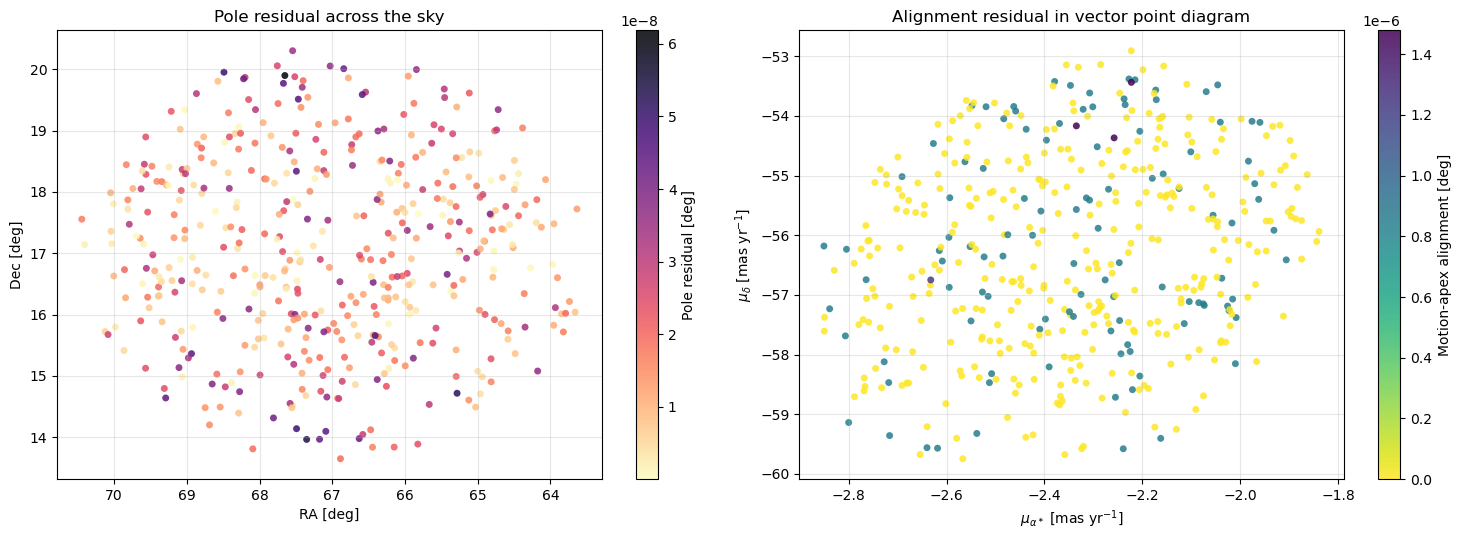


Returned objects
summary_df : global validation metrics
df_diag    : star-by-star diagnostic table
boot_df    : bootstrap apex table


In [79]:
summary_df, df_diag, boot_df = show_cluster_validation_products_icrs(
    result_hyades_sintetico_solar["cluster_result"],
    bootstrap_n=500,
)